# 04 · Topic Analysis

Post-processes raw BERTopic output and produces topic-level visualisations.

**Prerequisite:** Run  first.


In [1]:
import sys
sys.path.append("../functions")

import math
from collections import defaultdict, Counter
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    RESULTS_DIR, FIGURES_DIR,
    FINETUNED_MODEL_DIR,
    TOPIC_RUN_DATE,
    TOPIC_COLOURS, HOUSING_ORDER, HOUSING_TYPE_COLOURS, INNER_LONDON_BOROUGHS,
)
from data_loader import load_topics, build_comment_topic_df
from topic_processing import process_topics, build_topic_names

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Load and process topics

In [2]:
comment_df = pd.read_parquet(RESULTS_DIR / "comments.parquet")
pld_df     = pd.read_parquet(RESULTS_DIR / "pld.parquet")

raw_tp_df = load_topics(env="dev")
tp_df     = process_topics(raw_tp_df)  # filter bad topics, collapse duplicates

raw_topic_names = pd.read_csv(FINETUNED_MODEL_DIR / "object_topics.csv")
topic_names     = build_topic_names(raw_topic_names)

print(f"Unique topic groups after processing: {topic_names['Topic'].nunique()}")
topic_names.head()


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Unique topic groups after processing: 59


,Topic,Count,Name,topic_group,color
0,1,12881,1_parking_traffic_already_spaces,impact on parking,#336589
1,2,7970,2_garden_trees_green_space,loss of gardens,#aad874
2,3,7511,3_design_character_out_of,out of character,#fba337
3,4,6291,4_access_to_the_for,construction access,#b63838
4,5,5213,5_height_scale_buildings_of,too tall,#a373d0


## Merge comments with topics and planning data

In [3]:
df = build_comment_topic_df(comment_df, tp_df, pld_df, TOPIC_RUN_DATE)
print(f"Comment–topic DataFrame: {len(df):,} rows")
df.head()


Comment–topic DataFrame: 30,424 rows


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number,probability,lpa_app_no_borough,housing_type,total_no_proposed_residential_units
0,69996,Lambeth,22/01569/FUL_13,22/01569/FUL,None,Objects,2022-06-27,I am strongly opposed to this planning applica...,2025-04-04,NaN,NaN,I am strongly opposed to this planning applica...,None,-0.169995,"[11, 6, 16, 8, 1, 4]","[0.7162463225296108, 0.4100961363127592, 1.0, ...",22/01569/FUL_Lambeth,Market housing,9.0
1,69999,Lambeth,22/01569/FUL_16,22/01569/FUL,None,Objects,2022-06-27,I strongly object to this planning application...,2025-04-04,NaN,NaN,I strongly object to this planning application...,None,-0.474422,"[3, 12, 7, 1, 2, 16, 4]","[1.0, 1.0, 1.0, 1.0, 1.0, 0.935262704584908, 0...",22/01569/FUL_Lambeth,Market housing,9.0
2,70001,Lambeth,22/01569/FUL_18,22/01569/FUL,None,Objects,2022-06-27,I have read all the documents as a close neigh...,2025-04-04,NaN,NaN,I have read all the documents as a close neigh...,None,-0.352204,"[2, 14, 38, 1]","[1.0, 1.0, 0.32324363648956667, 0.124009209787...",22/01569/FUL_Lambeth,Market housing,9.0
3,70008,Lambeth,22/01569/FUL_25,22/01569/FUL,None,Objects,2022-06-27,I am very concerned what this development woul...,2025-04-04,NaN,NaN,I am very concerned what this development woul...,None,-0.605155,[14],[0.11157225800033421],22/01569/FUL_Lambeth,Market housing,9.0
4,70009,Lambeth,22/01569/FUL_26,22/01569/FUL,None,Objects,2022-06-27,Worry for children's safety as this build will...,2025-04-04,NaN,NaN,Worry for children's safety as this build will...,None,-0.482568,[16],[1.0],22/01569/FUL_Lambeth,Market housing,9.0


## Topic frequency (all London)

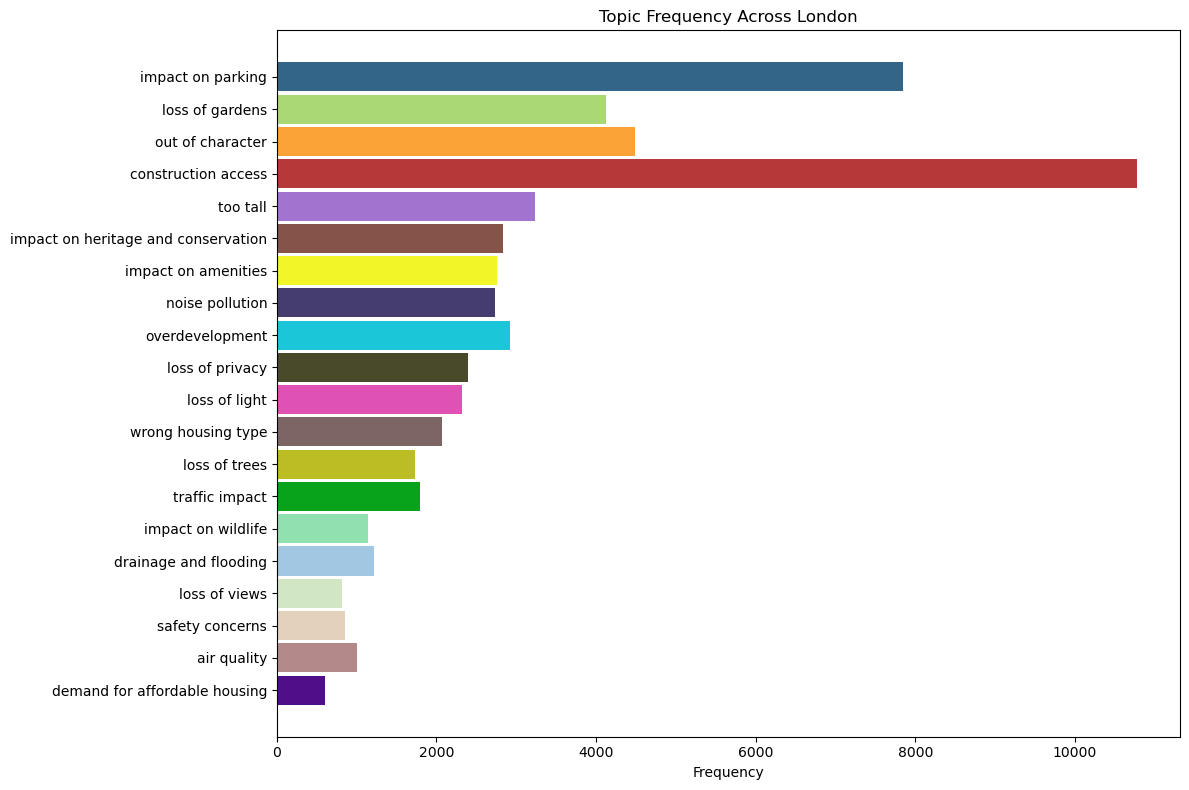

In [4]:
all_topics  = df["topic_number"].explode()
topic_counts = all_topics.value_counts().rename("count")

plot_df = (
    topic_names[["Topic", "topic_group", "color"]]
    .merge(topic_counts, left_on="Topic", right_index=True, how="left")
    .fillna({"count": 0})
)
plot_df["Percentage"] = (plot_df["count"] / plot_df["count"].sum() * 100).round(2)

n_vals = 20
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_df["topic_group"].iloc[:n_vals],
        plot_df["count"].iloc[:n_vals],
        color=plot_df["color"].iloc[:n_vals], height=0.9)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Topic Frequency Across London")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_frequency.png", dpi=150, bbox_inches="tight")
plt.show()


## Inner vs outer London split

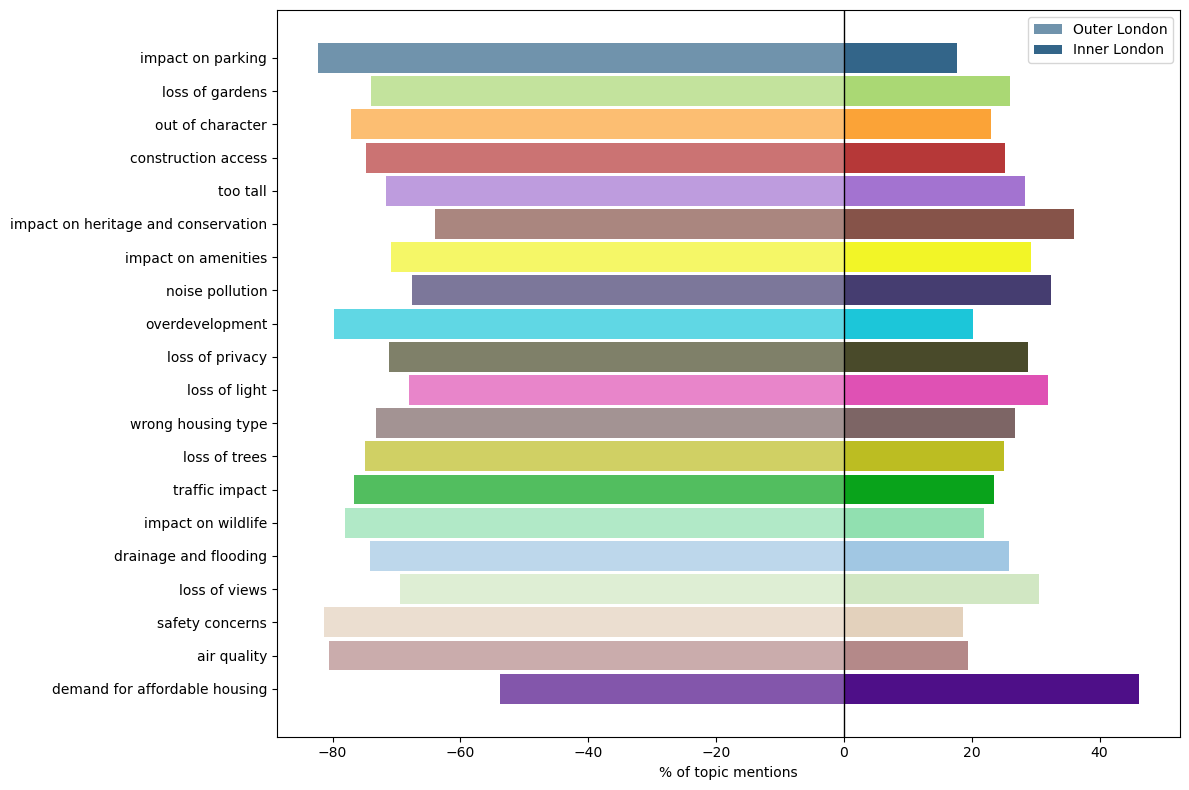

In [5]:
outer_boroughs = [c for c in df["council"].unique() if c not in INNER_LONDON_BOROUGHS]

inner_counts = (df[df["council"].isin(INNER_LONDON_BOROUGHS)]["topic_number"]
                .explode().value_counts().rename("inner"))
outer_counts = (df[df["council"].isin(outer_boroughs)]["topic_number"]
                .explode().value_counts().rename("outer"))

plot_df = plot_df.merge(inner_counts, left_on="Topic", right_index=True, how="left")
plot_df = plot_df.merge(outer_counts, left_on="Topic", right_index=True, how="left")
plot_df[["inner", "outer"]] = plot_df[["inner", "outer"]].fillna(0)

total = plot_df["inner"] + plot_df["outer"]
plot_df["inner_pct"] = (plot_df["inner"] / total * 100).round(2)
plot_df["outer_pct"] = (plot_df["outer"] / total * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_df["topic_group"].iloc[:n_vals],
        -plot_df["outer_pct"].iloc[:n_vals],
        color=plot_df["color"].iloc[:n_vals], height=0.9, alpha=0.7, label="Outer London")
ax.barh(plot_df["topic_group"].iloc[:n_vals],
        plot_df["inner_pct"].iloc[:n_vals],
        color=plot_df["color"].iloc[:n_vals], height=0.9, label="Inner London")
ax.axvline(0, color="black", linewidth=1)
ax.invert_yaxis()
ax.set_xlabel("% of topic mentions")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_inner_outer_london.png", dpi=150, bbox_inches="tight")
plt.show()


## Topics by housing type

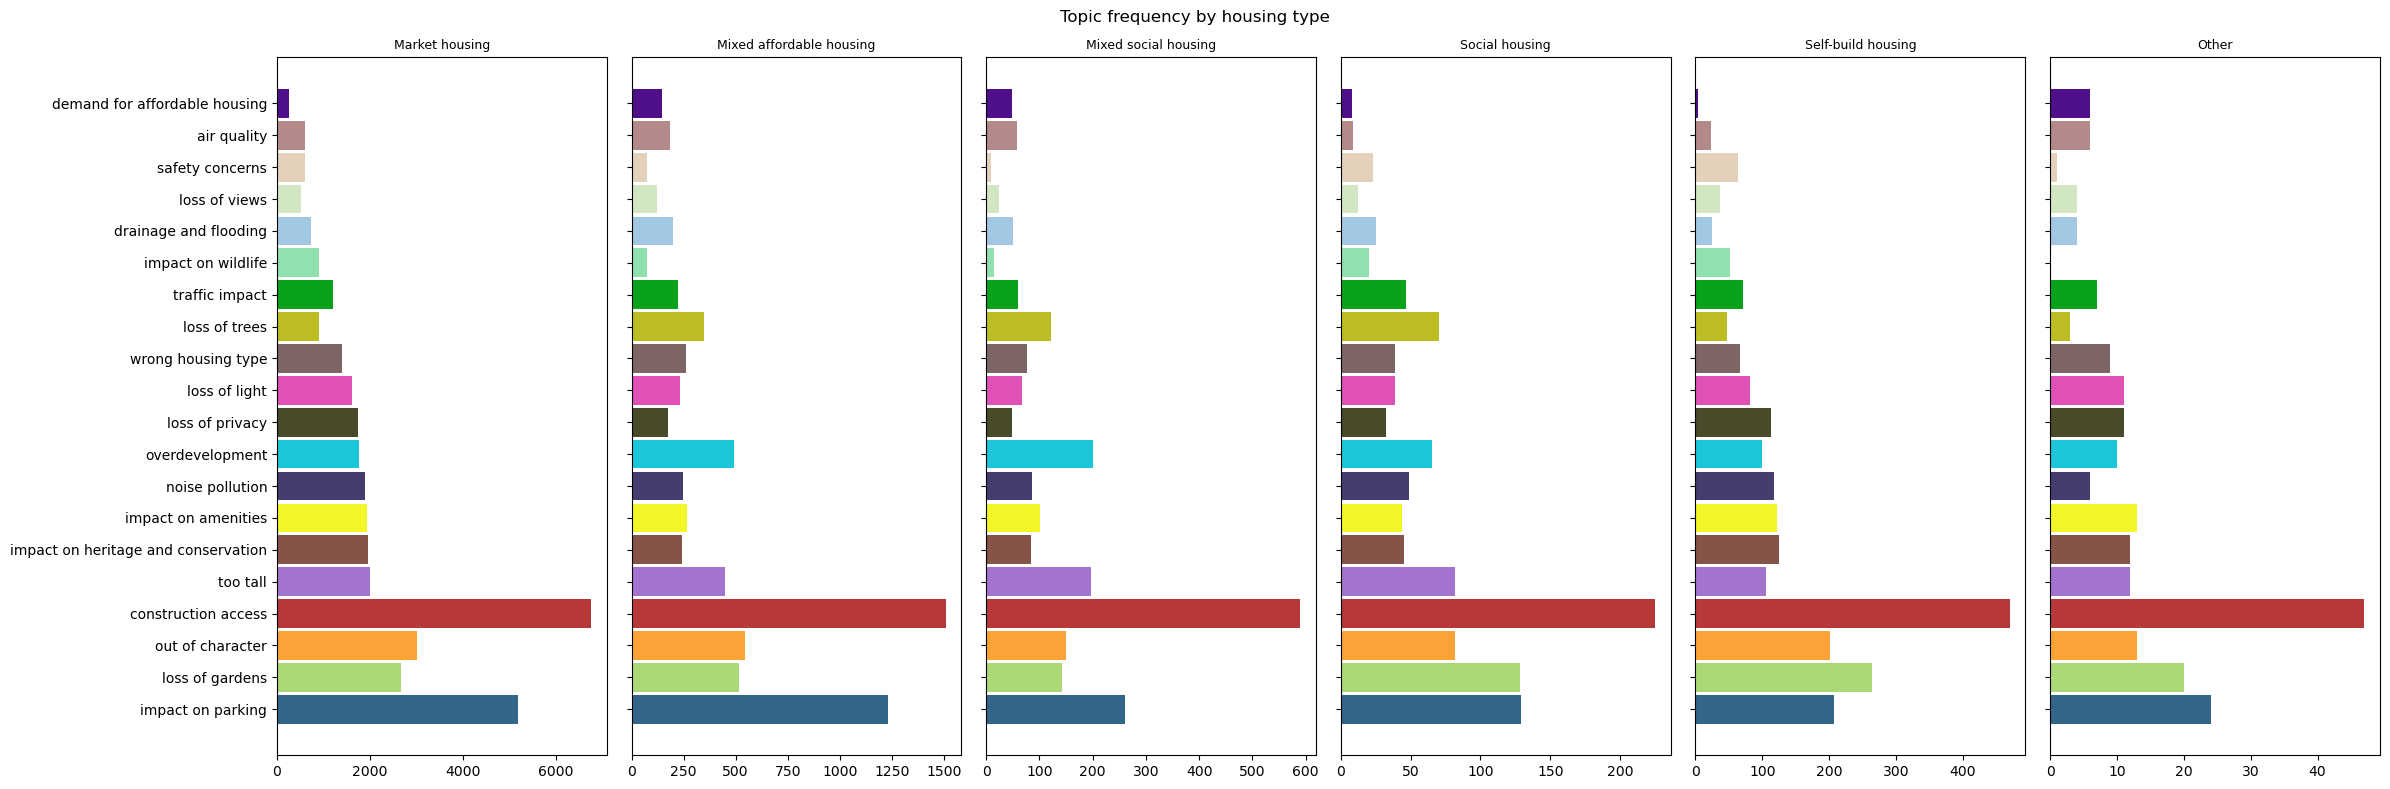

In [6]:
desired_order = [h for h in HOUSING_ORDER if h in df["housing_type"].dropna().unique()]

fig, axes = plt.subplots(1, len(desired_order), figsize=(4 * len(desired_order), 8), sharey=True)

for ax, ht in zip(axes, desired_order):
    ht_counts = (
        df[df["housing_type"] == ht]["topic_number"]
        .explode().value_counts().rename("count")
    )
    sub = (
        topic_names[["Topic", "topic_group", "color"]]
        .merge(ht_counts, left_on="Topic", right_index=True, how="left")
        .fillna({"count": 0})
        .iloc[:n_vals]
    )
    ax.barh(sub["topic_group"], sub["count"], color=sub["color"], height=0.9)
    ax.invert_yaxis()
    ax.set_title(ht, fontsize=9)

plt.suptitle("Topic frequency by housing type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_by_housing_type.png", dpi=150, bbox_inches="tight")
plt.show()


## Sentiment by topic

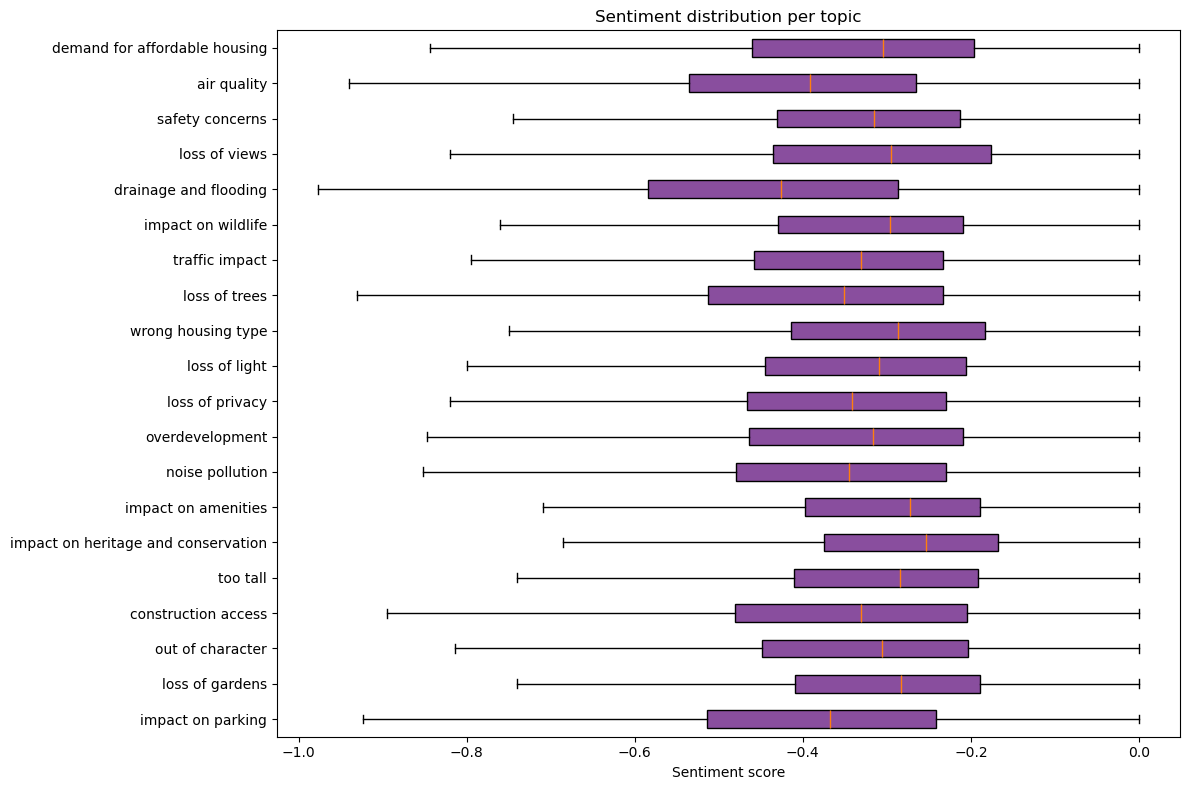

In [7]:
n_vals = 20
fig, ax = plt.subplots(figsize=(12, 8))
data  = [
    df.explode("topic_number").loc[
        lambda d: d["topic_number"] == t, "sentiment_score"
    ].dropna()
    for t in plot_df["Topic"].iloc[:n_vals]
]
ax.boxplot(data, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#894e9e"), showfliers=False)
ax.set_yticks(range(1, n_vals + 1))
ax.set_yticklabels(plot_df["topic_group"].iloc[:n_vals])
ax.set_xlabel("Sentiment score")
ax.set_title("Sentiment distribution per topic")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()


## Topic co-occurrence (top 15)

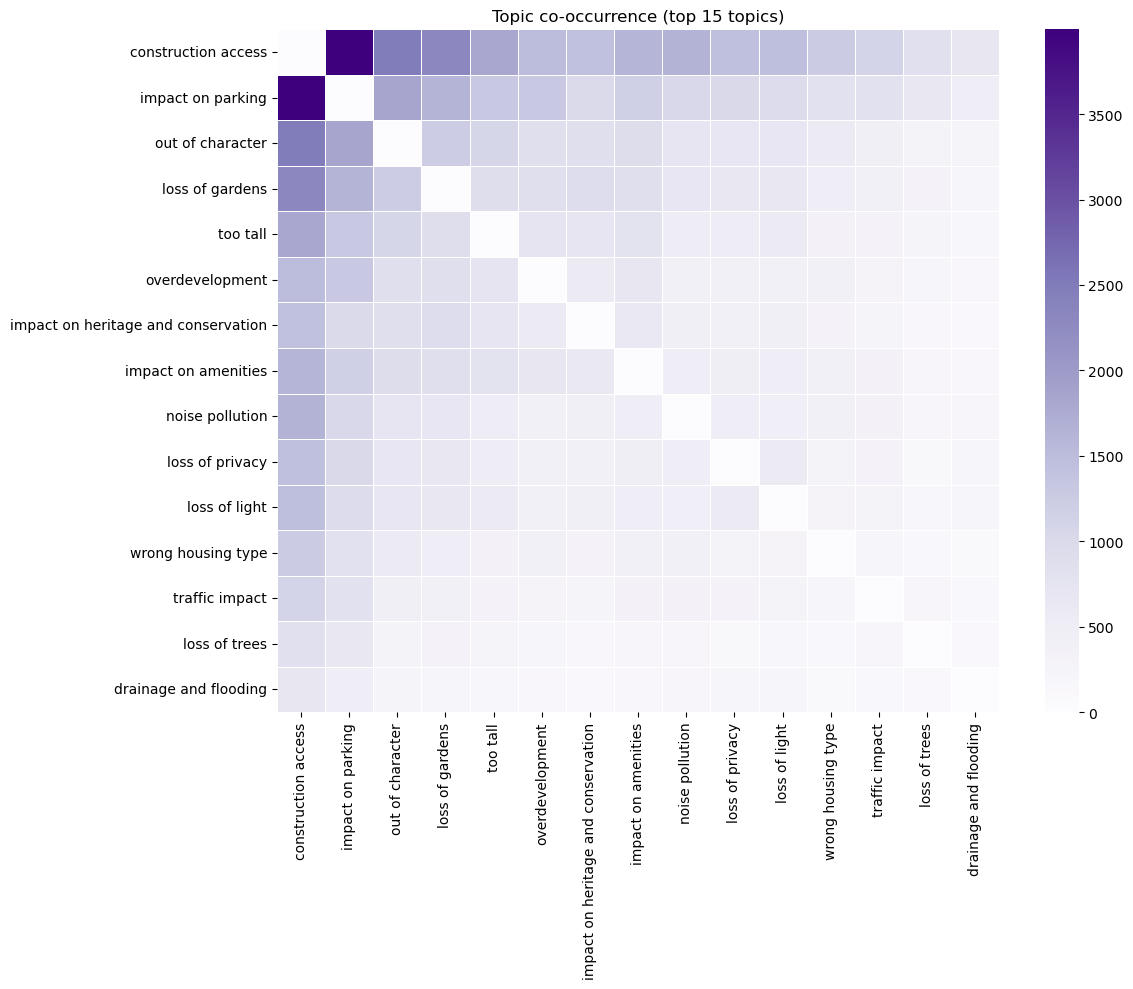

In [8]:
top15 = [t for t, _ in Counter(df["topic_number"].explode().dropna()).most_common(15)]

co = defaultdict(lambda: defaultdict(int))
for topics in df["topic_number"].dropna():
    for t1, t2 in combinations(set(topics) & set(top15), 2):
        co[t1][t2] += 1
        co[t2][t1] += 1

matrix = pd.DataFrame(0, index=top15, columns=top15)
for t1 in top15:
    for t2 in top15:
        matrix.loc[t1, t2] = co[t1][t2]

topic_name_lookup = topic_names.set_index("Topic")["topic_group"].to_dict()
matrix.index   = [topic_name_lookup.get(t, t) for t in matrix.index]
matrix.columns = [topic_name_lookup.get(t, t) for t in matrix.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matrix, ax=ax, cmap="Purples", linewidths=0.5)
ax.set_title("Topic co-occurrence (top 15 topics)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()
